<a href="https://colab.research.google.com/github/swabhimansahu2004/Hybrid-TinyML-Environmental-Monitoring/blob/Swabhiman_Teacher_Model/Phase_3_Student_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load Data
df = pd.read_csv('smoke_detection_iot.csv')

# 2. Re-create Feature Set (Dropping metadata/leaked features)
features = ['Humidity[%]', 'Pressure[hPa]', 'Raw H2', 'NC2.5', 'NC1.0',
            'PM2.5', 'eCO2[ppm]', 'PM1.0', 'NC0.5', 'Temperature[C]',
            'TVOC[ppb]', 'Raw Ethanol']
X = df[features]
y = df['Fire Alarm']

# 3. Synchronize Split (MUST use random_state=42 to match Phase 1)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.125, random_state=42)

# 4. Standardize (Ensuring the Student sees the same scale as the Teacher)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 5. Load the Expert Teacher Model
# Ensure 'teacher_model.h5' is uploaded to your current session
teacher_model = tf.keras.models.load_model('teacher_model.h5')
print("✅ Expert Teacher Loaded and Data Synchronized.")

✅ Expert Teacher Loaded and Data Synchronized.


In [3]:
class Distiller(tf.keras.Model):
    def __init__(self, student, teacher):
        super(Distiller, self).__init__()
        self.teacher = teacher
        self.student = student

    def compile(self, optimizer, metrics, student_loss_fn, distillation_loss_fn, alpha=0.1, temperature=3):
        super(Distiller, self).compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        # Teacher provides the "Soft Labels" (logic)
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)

            # Loss against ground truth
            student_loss = self.student_loss_fn(y, student_predictions)

            # Loss against teacher's knowledge (KL Divergence)
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            )

            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        # Update Student weights
        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)
        self.compiled_metrics.update_state(y, y_prediction)
        return {m.name: m.result() for m in self.metrics}

In [6]:
# Define 3 architectures to compare complexity vs accuracy
student_configs = {
    "Student_A": [16, 8],
    "Student_B": [8, 4],
    "Student_C": [4, 2]
}

results = []
histories = {}
trained_models = {}

for name, neurons in student_configs.items():
    print(f"\n🚀 Researching {name}...")

    # Create the specific architecture
    student = tf.keras.Sequential([
        tf.keras.layers.Dense(neurons[0], activation='relu', input_shape=(len(features),)),
        tf.keras.layers.Dense(neurons[1], activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ], name=name)

    # Distill intelligence
    distiller = Distiller(student=student, teacher=teacher_model)
    distiller.compile(
        optimizer=tf.keras.optimizers.Adam(),
        metrics=['accuracy'],
        student_loss_fn=tf.keras.losses.BinaryCrossentropy(),
        distillation_loss_fn=tf.keras.losses.KLDivergence(),
        alpha=0.1,
        temperature=3
    )

    # Train
    history = distiller.fit(X_train, y_train, validation_data=(X_val, y_val),
                            epochs=60, batch_size=32, verbose=1)

    # Evaluate size and performance
   # 1. Compile the student specifically so it can be evaluated
    student.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # 2. Evaluate performance
    loss, test_acc = student.evaluate(X_test, y_test, verbose=0)

    # 3. Logging results
    histories[name] = history.history
    trained_models[name] = student
    results.append({
        "Model": name,
        "Accuracy": test_acc * 100,
        "Parameters": student.count_params()
    })
    print(f"✅ {name} Score: {test_acc*100:.2f}% | Params: {student.count_params()}")


🚀 Researching Student_A...
Epoch 1/60
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9598 - loss: 0.6903 - val_loss: 0.7178
Epoch 2/60
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9673 - loss: 0.7145 - val_loss: 0.7155
Epoch 3/60
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9746 - loss: 0.7149 - val_loss: 0.7116
Epoch 4/60
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9821 - loss: 0.7151 - val_loss: 0.7170
Epoch 5/60
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9858 - loss: 0.7151 - val_loss: 0.7088
Epoch 6/60
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9893 - loss: 0.7151 - val_loss: 0.7111
Epoch 7/60
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9898 - loss: 0.7150 - val_loss: 0.7175
Epoch 8/60
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9915 - loss: 0.7151 - val_loss: 0.7162
Epoch 9/60
1371/1371 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9927 - loss: 0.7152 - val_loss: 0.7089
Epoch 10/

In [8]:
results_df = pd.DataFrame(results)
print(results_df)

       Model   Accuracy  Parameters
0  Student_A  99.888235         353
1  Student_B  99.768484         145
2  Student_C  98.922241          65


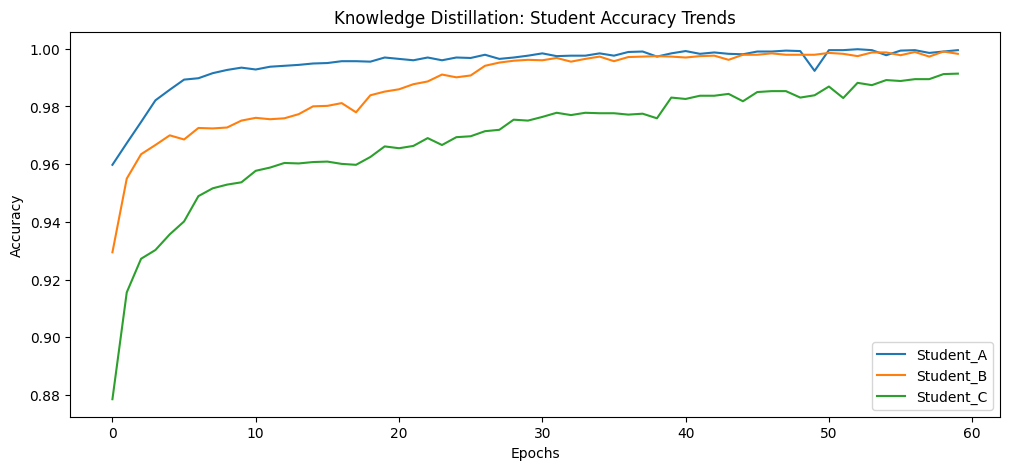

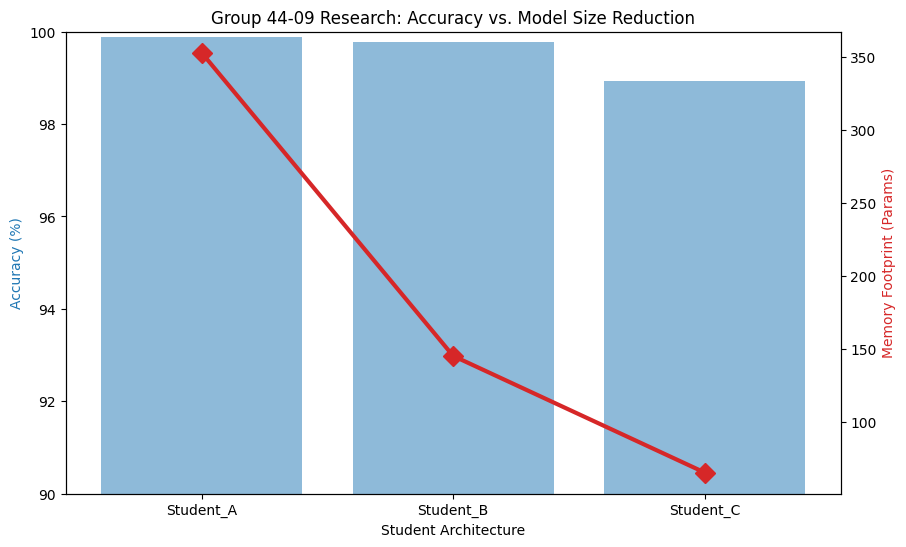


🏆 Recommended Winner for ESP32 Deployment: Student_A
💾 Saved as 'best_distilled_student.h5' for Phase 3.


In [9]:
import matplotlib.pyplot as plt

# --- Chart 1: Learning Trends ---
plt.figure(figsize=(12, 5))
for name, hist in histories.items():
    plt.plot(hist['accuracy'], label=name)
plt.title('Knowledge Distillation: Student Accuracy Trends')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()

# --- Chart 2: Pareto Frontier (Research Evidence) ---
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Student Architecture')
ax1.set_ylabel('Accuracy (%)', color='tab:blue')
ax1.bar(results_df['Model'], results_df['Accuracy'], color='tab:blue', alpha=0.5)
ax1.set_ylim(90, 100)

ax2 = ax1.twinx()
ax2.set_ylabel('Memory Footprint (Params)', color='tab:red')
ax2.plot(results_df['Model'], results_df['Parameters'], color='tab:red', marker='D', markersize=10, linewidth=3)

plt.title('Group 44-09 Research: Accuracy vs. Model Size Reduction')
plt.show()

# Save the optimal winner
winner_idx = results_df['Accuracy'].idxmax()
winner_name = results_df.loc[winner_idx, 'Model']
print(f"\n🏆 Recommended Winner for ESP32 Deployment: {winner_name}")

trained_models[winner_name].save('best_distilled_student.h5')
print(f"💾 Saved as 'best_distilled_student.h5' for Phase 3.")